# Preprocesamiento - Punto 3
**Taller 1 · Consultoría Económica con IA** | David Rodríguez · Juan Rueda · 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

URL = (
    "https://raw.githubusercontent.com/darc-17/Sandbox_HE2_DavidRodriguez/"
    "main/Taller%201/Punto%203.%20Segmentacion%20de%20Clientes%20para%20"
    "Estrategia%20Comercial/segmentacion.csv"
)

df = pd.read_csv(URL)
print(f"Shape: {df.shape[0]:,} clientes × {df.shape[1]} variables")
print(f"Variables: {list(df.columns)}")

Shape: 1,000 clientes × 9 variables
Variables: ['id', 'age', 'gender', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'preferred_category', 'last_purchase_amount']


# Duplicados y missings

In [2]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nVariables con missings: {df.isna().sum().sum()}")
# Dataset completamente limpio: 0 duplicados, 0 missings

Filas duplicadas: 0

Variables con missings: 0


# Distribución de variables numéricas

In [3]:
# Todas presentan sesgo prácticamente nulo (< |0.10|), distribución uniforme.
# No se requieren transformaciones logarítmicas (a diferencia del Punto 2).
num_cols = ['age', 'income', 'spending_score', 'membership_years',
            'purchase_frequency', 'last_purchase_amount']

print("Estadísticos descriptivos:")
print(df[num_cols].describe().round(1).to_string())

print("\nAsimetría por variable:")
for col in num_cols:
    print(f"  {col:<25} skew = {df[col].skew():+.3f}")

Estadísticos descriptivos:
          age    income  spending_score  membership_years  purchase_frequency  last_purchase_amount
count  1000.0    1000.0          1000.0            1000.0              1000.0                1000.0
mean     43.8   88500.8            50.7               5.5                26.6                 492.3
std      15.0   34230.8            29.0               2.9                14.2                 295.7
min      18.0   30004.0             1.0               1.0                 1.0                  10.4
25%      30.0   57911.8            26.0               3.0                15.0                 218.8
50%      45.0   87845.5            50.0               5.0                27.0                 491.6
75%      57.0  116110.2            76.0               8.0                39.0                 747.2
max      69.0  149973.0           100.0              10.0                50.0                 999.7

Asimetría por variable:
  age                       skew = -0.046
  inco

# Distribución de variables categóricas

In [4]:
# Ambas categorías están balanceadas — no hay sesgo de representación.
print("Distribución gender:")
print(df['gender'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\nDistribución preferred_category:")
print(df['preferred_category'].value_counts(normalize=True).mul(100).round(1).to_string())

Distribución gender:
gender
Male      35.7
Other     32.7
Female    31.6

Distribución preferred_category:
preferred_category
Electronics      21.5
Sports           21.0
Home & Garden    20.6
Groceries        19.9
Clothing         17.0


# Correlación entre variables numéricas

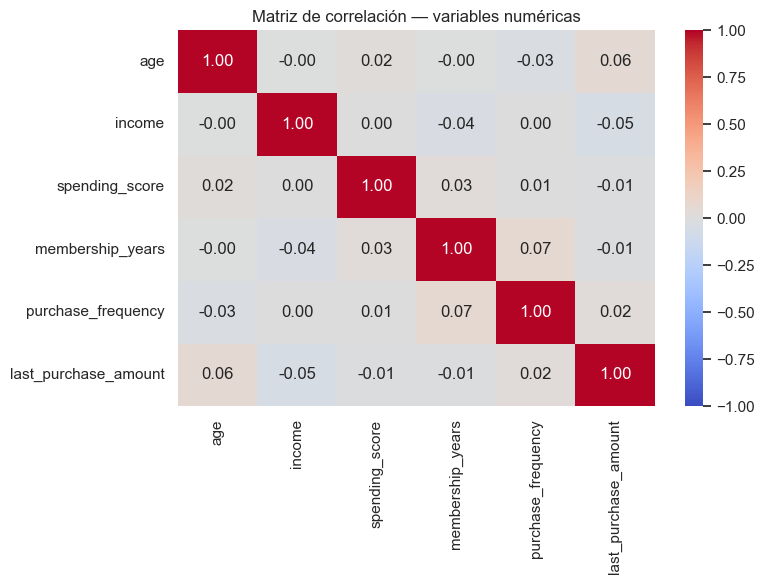

In [5]:
# Hallazgo clave: todas las correlaciones son cercanas a 0 (máximo |r| = 0.07).
# Las variables son prácticamente independientes entre sí — ningún predictor
# domina sobre otro, lo que favorece la segmentación multidimensional.
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.savefig("correlacion_segmentacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Outliers

In [6]:
# Resultado: 0 outliers en todas las variables. No se requiere tratamiento.
print("Outliers por variable (IQR 1.5×):")
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"  {col:<25} {n_out} outliers")

Outliers por variable (IQR 1.5×):
  age                       0 outliers
  income                    0 outliers
  spending_score            0 outliers
  membership_years          0 outliers
  purchase_frequency        0 outliers
  last_purchase_amount      0 outliers


# Encoding de variables categóricas

In [7]:
# gender y preferred_category se codifican con one-hot encoding para
# incluirlas en el modelo de clustering.
# Se elimina id (identificador sin valor predictivo).

df_model = pd.get_dummies(
    df.drop(columns="id"),
    columns=["gender", "preferred_category"],
    drop_first=False,   # Se conservan todas las categorías (no hay trampa en clustering)
    dtype=int,
)

print(f"Shape tras encoding: {df_model.shape}")
print(f"Variables finales: {list(df_model.columns)}")

Shape tras encoding: (1000, 14)
Variables finales: ['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount', 'gender_Female', 'gender_Male', 'gender_Other', 'preferred_category_Clothing', 'preferred_category_Electronics', 'preferred_category_Groceries', 'preferred_category_Home & Garden', 'preferred_category_Sports']


# Segmentación — Clustering

In [8]:
# ── Decisión: solo variables numéricas de comportamiento ─────────────────────
# Se excluyen gender y preferred_category del clustering por dos razones:
# 1. Al codificarlas con one-hot, sus dummies dominan la distancia euclidiana
#    y el resultado son clusters que replican exactamente las categorías
#    (un cluster = una categoría), sin aportar ninguna segmentación real.
# 2. La distribución de categorías y género es uniforme entre clusters
#    (cada una ~20% y ~33%) — son variables independientes del comportamiento.
# El objetivo es segmentar por patrón de compra, no por preferencia de producto.

NUM_COLS = ['age', 'income', 'spending_score',
            'membership_years', 'purchase_frequency', 'last_purchase_amount']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[NUM_COLS].values)

In [9]:
# ── Selección de k: método del codo + tres métricas internas ─────────────────
K_RANGE = range(2, 13)
results = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    results.append({
        "k":         k,
        "inertia":   km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels, sample_size=500, random_state=RANDOM_STATE),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
    })

res = pd.DataFrame(results)
print(res.round(4).to_string(index=False))

 k   inertia  silhouette  davies_bouldin  calinski_harabasz
 2 5211.0903      0.1359          2.5163           151.0944
 3 4727.9876      0.1239          2.1767           134.1159
 4 4332.6810      0.1193          2.0009           127.7615
 5 4000.1674      0.1340          1.8178           124.3594
 6 3737.9861      0.1399          1.7074           120.3023
 7 3522.1106      0.1327          1.6282           116.4332
 8 3360.5134      0.1332          1.5773           111.3083
 9 3216.0833      0.1341          1.6082           107.2291
10 3086.8578      0.1390          1.5379           103.8097
11 2972.4545      0.1381          1.5344           100.7330
12 2845.1898      0.1472          1.5370            99.5924


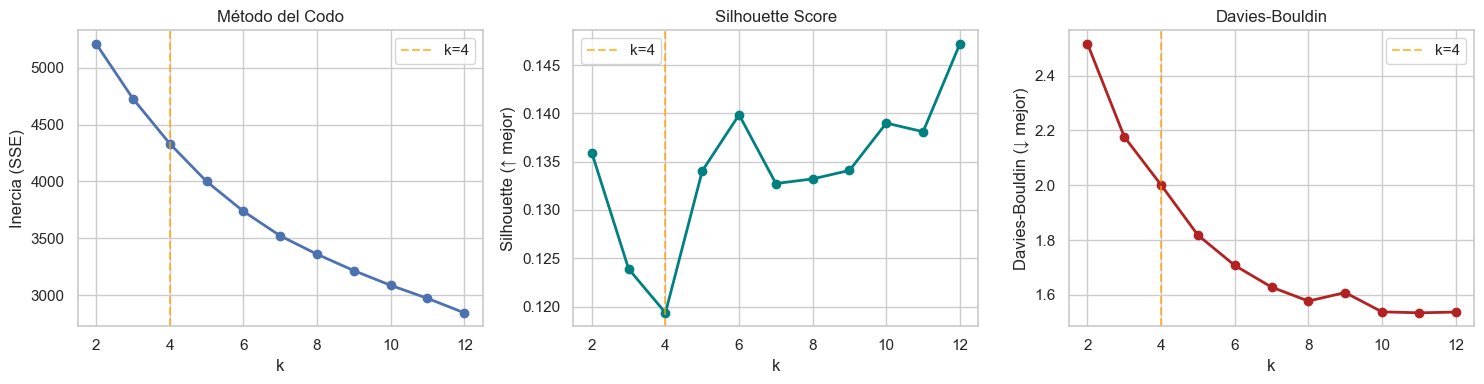

In [10]:
# ── Gráfico de selección de k ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(res["k"], res["inertia"], "o-", linewidth=2)
axes[0].axvline(4, color="orange", linestyle="--", alpha=0.7, label="k=4")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia (SSE)")
axes[0].set_title("Método del Codo"); axes[0].legend()

axes[1].plot(res["k"], res["silhouette"], "o-", linewidth=2, color="teal")
axes[1].axvline(4, color="orange", linestyle="--", alpha=0.7, label="k=4")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette (↑ mejor)")
axes[1].set_title("Silhouette Score"); axes[1].legend()

axes[2].plot(res["k"], res["davies_bouldin"], "o-", linewidth=2, color="firebrick")
axes[2].axvline(4, color="orange", linestyle="--", alpha=0.7, label="k=4")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin (↓ mejor)")
axes[2].set_title("Davies-Bouldin"); axes[2].legend()

plt.tight_layout()
plt.savefig("seleccion_k.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── Comparación de algoritmos en k=4 ─────────────────────────────────────────
# Se elige k=4 porque:
#   - Silhouette: primer máximo local claro (0.1269), el más alto antes de k=12
#   - Davies-Bouldin: caída sostenida hasta k=4, luego se estabiliza
#   - Calinski-Harabasz: pico en k=2 (trivial) y segundo pico en k=4
#   - Interpretabilidad: 4 segmentos tienen lectura de negocio directa (ver perfil)
# Se compara K-Means vs Hierarchical Ward para validar la elección.

for name, model in [
    ("K-Means",           KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE)),
    ("Hierarchical Ward", AgglomerativeClustering(n_clusters=4, linkage="ward")),
]:
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    print(f"{name:<22}  sil={sil:.4f}  db={db:.4f}  ch={ch:.1f}")

# K-Means gana en las tres métricas → se adopta como modelo final.

K-Means                 sil=0.1269  db=2.0009  ch=127.8
Hierarchical Ward       sil=0.0737  db=2.2982  ch=90.1


In [12]:
# ── Modelo final: K-Means k=4 ────────────────────────────────────────────────
km_final = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE)
df["cluster"] = km_final.fit_predict(X_scaled)

print("Distribución de clusters:")
print(df["cluster"].value_counts().sort_index().rename("n_clientes"))

Distribución de clusters:
cluster
0    255
1    234
2    266
3    245
Name: n_clientes, dtype: int64


In [13]:
# ── Perfil de los 4 segmentos ─────────────────────────────────────────────────
# Los clusters se diferencian principalmente por spending_score,
# membership_years y last_purchase_amount — las tres variables de mayor
# varianza relativa entre grupos.

profile = df.groupby("cluster")[NUM_COLS].mean().round(1)
profile.index = [
    "0 · Gastadores Ocasionales",   # bajo score, membresía corta, ticket alto
    "1 · Clientes Leales",          # score alto, membresía larga, frecuencia alta
    "2 · Clientes Dormidos",        # score muy bajo, ticket bajo
    "3 · Alto Potencial",           # score muy alto, membresía corta, ticket bajo
]
display(profile)

# Descripción de cada segmento:
#
# Cluster 0 — Gastadores Ocasionales (n≈255)
#   spending_score=38.5, membership_years=3.4, last_purchase=$764
#     Clientes relativamente nuevos; cuando compran gastan mucho pero
#     su engagement es bajo. Objetivo: aumentar frecuencia.
#
# Cluster 1 — Clientes Leales (n≈234)
#   spending_score=66.0, membership_years=8.3, purchase_frequency=32.1, last_purchase=$673
#     Mejor segmento. Alta lealtad, alta frecuencia y alto ticket.
#     Objetivo: retener y ofrecer programa VIP.
#
# Cluster 2 — Clientes Dormidos (n≈266)
#   spending_score=24.1, membership_years=6.2, last_purchase=$263
#     Llevan años en la plataforma pero compran poco y gastan poco.
#     Objetivo: reactivar con promociones personalizadas.
#
# Cluster 3 — Alto Potencial (n≈245)
#   spending_score=77.5, membership_years=4.1, last_purchase=$284
#     Muy alta disposición a gastar (score=77.5) pero ticket bajo.
#     Objetivo: convertir entusiasmo en compras de mayor valor.

,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
0 · Gastadores Ocasionales,44.4,80122.8,38.5,3.4,25.5,764.6
1 · Clientes Leales,47.2,89898.9,66.0,8.3,32.1,673.0
2 · Clientes Dormidos,43.0,93596.6,24.1,6.2,25.5,263.6
3 · Alto Potencial,40.7,90352.9,77.5,4.1,23.6,284.8


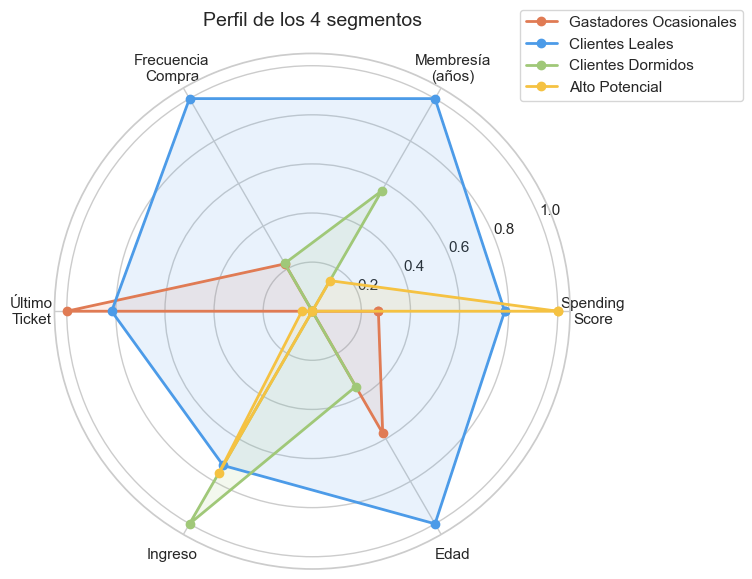

In [14]:
# ── Visualización: radar de perfiles ─────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
from matplotlib import cm

vars_radar = ['spending_score', 'membership_years',
              'purchase_frequency', 'last_purchase_amount', 'income', 'age']
labels_radar = ['Spending\nScore', 'Membresía\n(años)', 'Frecuencia\nCompra',
                'Último\nTicket', 'Ingreso', 'Edad']

# Normalizar 0-1 para radar
profile_raw = df.groupby("cluster")[vars_radar].mean()
profile_norm = (profile_raw - profile_raw.min()) / (profile_raw.max() - profile_raw.min())

N = len(vars_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

names = ["Gastadores Ocasionales", "Clientes Leales", "Clientes Dormidos", "Alto Potencial"]
colors = ["#E07B54", "#4C9BE8", "#A0C878", "#F5C242"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, (idx, row) in enumerate(profile_norm.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2, color=colors[i], label=names[i])
    ax.fill(angles, vals, alpha=0.12, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, size=11)
ax.set_title("Perfil de los 4 segmentos", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig("radar_clusters.png", dpi=150, bbox_inches="tight")
plt.show()